# ***Importing Libraries***

In [412]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

# ***uploading Dataset***

In [413]:
df=pd.read_csv("/content/smart_home_device_usage_data.csv")

# ***Exploring DATASET***

In [414]:
df.head()

,UserID,DeviceType,UsageHoursPerDay,EnergyConsumption,UserPreferences,MalfunctionIncidents,DeviceAgeMonths,SmartHomeEfficiency
0,1,Smart Speaker,15.307188,1.961607,1,4,36,1
1,2,Camera,19.973343,8.610689,1,0,29,1
2,3,Security System,18.911535,2.651777,1,0,20,1
3,4,Camera,7.011127,2.341653,0,3,15,0
4,5,Camera,22.610684,4.859069,1,3,36,1


In [415]:
df.tail()

,UserID,DeviceType,UsageHoursPerDay,EnergyConsumption,UserPreferences,MalfunctionIncidents,DeviceAgeMonths,SmartHomeEfficiency
5398,5399,Thermostat,4.556314,5.871764,1,0,28,0
5399,5400,Lights,0.561856,1.555992,1,4,24,0
5400,5401,Smart Speaker,11.096236,7.677779,0,0,42,0
5401,5402,Security System,8.782169,7.467929,0,2,28,1
5402,5403,Thermostat,13.540381,9.043076,0,0,30,0


# ***Displaying DataFrame Shape***

In [416]:
df.shape

(5403, 8)

# ***Checking for Null Values***

In [417]:
df.isnull().sum()

,0
UserID,0
DeviceType,0
UsageHoursPerDay,0
EnergyConsumption,0
UserPreferences,0
MalfunctionIncidents,0
DeviceAgeMonths,0
SmartHomeEfficiency,0


# ***Descriptive Statistics of DataFrame***

In [418]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UserID,5403.0,2702.000000,1559.856083,1.000000,1351.500000,2702.000000,4052.500000,5403.000000
UsageHoursPerDay,5403.0,12.052992,6.714961,0.501241,6.297871,11.903768,17.791751,23.987326
EnergyConsumption,5403.0,5.054302,2.878941,0.101562,2.524968,5.007047,7.611912,9.998071
UserPreferences,5403.0,0.511753,0.499908,0.000000,0.000000,1.000000,1.000000,1.000000
MalfunctionIncidents,5403.0,2.066445,1.423291,0.000000,1.000000,2.000000,3.000000,4.000000
DeviceAgeMonths,5403.0,30.312234,16.990525,1.000000,15.000000,30.000000,45.000000,59.000000
SmartHomeEfficiency,5403.0,0.376643,0.484589,0.000000,0.000000,0.000000,1.000000,1.000000


# ***Checking for Duplicated Rows***

In [419]:
df.duplicated().sum()

np.int64(0)

# ***Counting Unique Values per Column***

In [420]:
df.nunique()

,0
UserID,5403
DeviceType,5
UsageHoursPerDay,5403
EnergyConsumption,5403
UserPreferences,2
MalfunctionIncidents,5
DeviceAgeMonths,59
SmartHomeEfficiency,2


# ***Counting MalfunctionIncidents***

In [421]:
df['MalfunctionIncidents'].value_counts()

,count
MalfunctionIncidents,
4,1155
3,1149
0,1049
2,1048
1,1002


# ***Displaying DataFrame Information***

In [422]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5403 entries, 0 to 5402
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   UserID                5403 non-null   int64  
 1   DeviceType            5403 non-null   object 
 2   UsageHoursPerDay      5403 non-null   float64
 3   EnergyConsumption     5403 non-null   float64
 4   UserPreferences       5403 non-null   int64  
 5   MalfunctionIncidents  5403 non-null   int64  
 6   DeviceAgeMonths       5403 non-null   int64  
 7   SmartHomeEfficiency   5403 non-null   int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 337.8+ KB


# ***Displaying DataFrame Columns***

In [423]:
df.columns

Index(['UserID', 'DeviceType', 'UsageHoursPerDay', 'EnergyConsumption',
       'UserPreferences', 'MalfunctionIncidents', 'DeviceAgeMonths',
       'SmartHomeEfficiency'],
      dtype='object')

# ***Counting DeviceType Values***

In [424]:
df['DeviceType'].value_counts()

,count
DeviceType,
Smart Speaker,1108
Camera,1101
Lights,1087
Security System,1068
Thermostat,1039


# ***Distribution of Device Types***

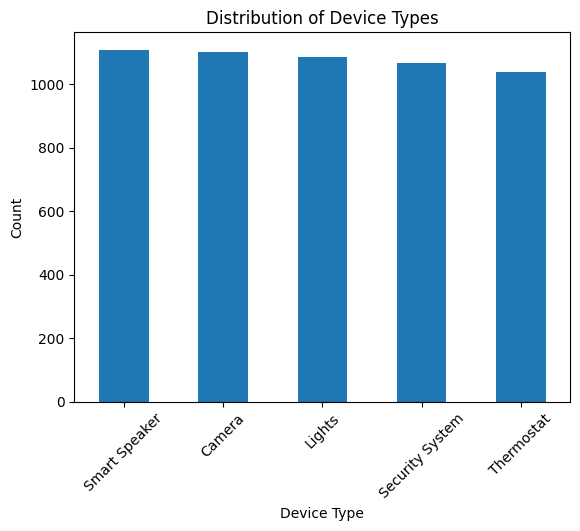

In [425]:

df["DeviceType"].value_counts().plot(kind="bar")

plt.title("Distribution of Device Types")
plt.xlabel("Device Type")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

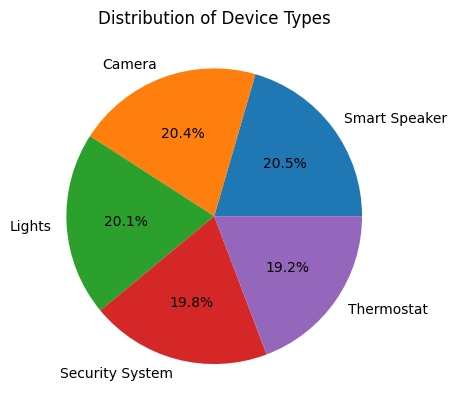

In [426]:
df['DeviceType'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of Device Types')
plt.ylabel('')
plt.show()

### Descriptive Statistics of UsageHoursPerDay

In [427]:
df["UsageHoursPerDay"].describe()

,UsageHoursPerDay
count,5403.000000
mean,12.052992
std,6.714961
min,0.501241
25%,6.297871
50%,11.903768
75%,17.791751
max,23.987326


### Counting SmartHomeEfficiency Values

In [428]:
df["SmartHomeEfficiency"].value_counts()

,count
SmartHomeEfficiency,
0,3368
1,2035


### Counting UserPreferences Values

In [429]:
df['UserPreferences'].value_counts()

,count
UserPreferences,
1,2765
0,2638


### Distribution of Smart Home Efficiency

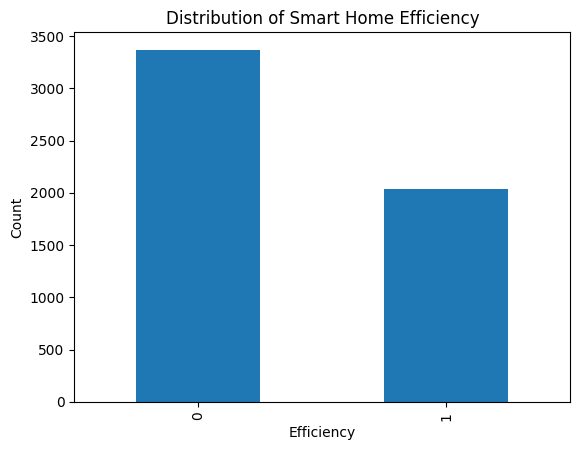

In [430]:
import matplotlib.pyplot as plt

df["SmartHomeEfficiency"].value_counts().plot(kind="bar")
plt.title("Distribution of Smart Home Efficiency")
plt.xlabel("Efficiency")
plt.ylabel("Count")
plt.show()

### Counting EnergyConsumption Values

In [431]:
df['EnergyConsumption'].value_counts()

,count
EnergyConsumption,
9.043076,1
1.961607,1
8.610689,1
2.651777,1
2.341653,1
...,...
9.665162,1
1.468928,1
7.385760,1


### Displaying DataFrame Data Types

In [432]:
df.dtypes

,0
UserID,int64
DeviceType,object
UsageHoursPerDay,float64
EnergyConsumption,float64
UserPreferences,int64
MalfunctionIncidents,int64
DeviceAgeMonths,int64
SmartHomeEfficiency,int64


### Feature Engineering: One-Hot Encoding DeviceType

In [433]:
df = pd.get_dummies(df, columns=['DeviceType'], drop_first=True, dtype=int)

### Displaying DataFrame After One-Hot Encoding

In [434]:
df

,UserID,UsageHoursPerDay,EnergyConsumption,UserPreferences,MalfunctionIncidents,DeviceAgeMonths,SmartHomeEfficiency,DeviceType_Lights,DeviceType_Security System,DeviceType_Smart Speaker,DeviceType_Thermostat
0,1,15.307188,1.961607,1,4,36,1,0,0,1,0
1,2,19.973343,8.610689,1,0,29,1,0,0,0,0
2,3,18.911535,2.651777,1,0,20,1,0,1,0,0
3,4,7.011127,2.341653,0,3,15,0,0,0,0,0
4,5,22.610684,4.859069,1,3,36,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
5398,5399,4.556314,5.871764,1,0,28,0,0,0,0,1
5399,5400,0.561856,1.555992,1,4,24,0,1,0,0,0
5400,5401,11.096236,7.677779,0,0,42,0,0,0,1,0
5401,5402,8.782169,7.467929,0,2,28,1,0,1,0,0


### Dropping UserID Column

In [435]:
df=df.drop(['UserID'],axis=1)

### Displaying DataFrame After Dropping UserID

In [436]:
df

,UsageHoursPerDay,EnergyConsumption,UserPreferences,MalfunctionIncidents,DeviceAgeMonths,SmartHomeEfficiency,DeviceType_Lights,DeviceType_Security System,DeviceType_Smart Speaker,DeviceType_Thermostat
0,15.307188,1.961607,1,4,36,1,0,0,1,0
1,19.973343,8.610689,1,0,29,1,0,0,0,0
2,18.911535,2.651777,1,0,20,1,0,1,0,0
3,7.011127,2.341653,0,3,15,0,0,0,0,0
4,22.610684,4.859069,1,3,36,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
5398,4.556314,5.871764,1,0,28,0,0,0,0,1
5399,0.561856,1.555992,1,4,24,0,1,0,0,0
5400,11.096236,7.677779,0,0,42,0,0,0,1,0
5401,8.782169,7.467929,0,2,28,1,0,1,0,0


### Defining Features (X) and Target (y)

In [437]:
X=df.drop(['SmartHomeEfficiency'],axis=1)
y=df['SmartHomeEfficiency']

In [438]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

### Logistic Regression Model Training

In [439]:
model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

### Predicting with Logistic Regression Model

In [440]:
y_pred=model.predict(X_test)

### Calculating Accuracy Score

In [441]:
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.8723404255319149


### Generating Confusion Matrix

In [442]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[609  69]
 [ 69 334]]


### Visualizing Confusion Matrix

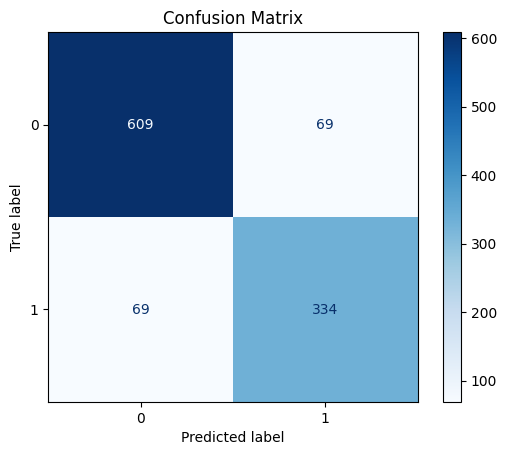

In [443]:
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

### K-Nearest Neighbors Model Training and Evaluation

In [444]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=7)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7197039777983348


### Decision Tree Classifier Training and Evaluation

In [445]:

model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9056429232192414


### Generating Confusion Matrix for Decision Tree

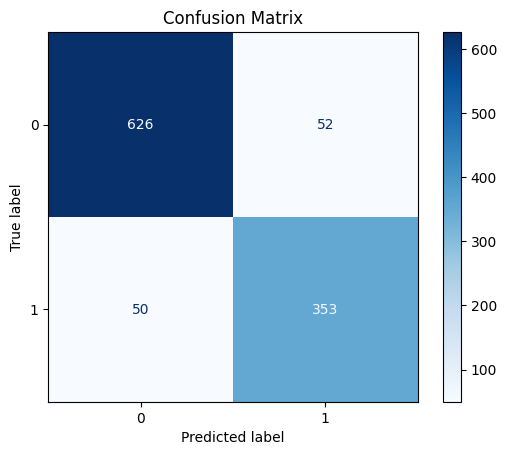

In [446]:
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

### Saving the Trained Model

In [447]:
import joblib

# Assuming the last trained model is the Decision Tree Classifier
# You can change the filename as needed
model_filename = 'decision_tree_model.pkl'
joblib.dump(model, model_filename)

print(f"Model saved to {model_filename}")

Model saved to decision_tree_model.pkl


### Downloading the Trained Model

In [448]:
from google.colab import files

files.download('decision_tree_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>